# 题目: 构建和使用长短时记忆神经网络（LSTM） - 使用 airline-passengers 数据集

在这个教程中，我们将介绍如何使用 Pytorch 构建和训练一个长短时记忆神经网络（LSTM）模型，然后使用该模型预测未来的乘客数量。我们将使用 [airline-passengers 数据集](https://www.kaggle.com/rakannimer/air-passengers)。

## 1. 加载数据

使用 pandas 加载数据集，并通过 matplotlib 可视化数据。

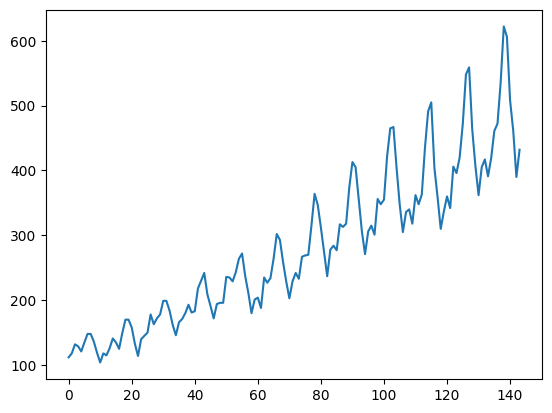

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('airline-passengers.csv')
timeseries = df[["Passengers"]].values.astype('float32')

plt.plot(timeseries)
plt.show()

* 时序数据归一化

对于时序数据，归一化对模型性能的影响至关重要。我们将使用 MinMaxScaler 对时序数据进行归一化，以便更好地训练 LSTM 模型。

In [2]:
from sklearn.preprocessing import MinMaxScaler

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
timeseries = scaler.fit_transform(timeseries)

## 2. 划分训练集和测试集

我们将数据集划分为训练集和测试集。我们将使用前三分之二的数据作为训练集，剩余的数据作为测试集。

注意：对时序数据而言，划分训练集和测试集时，不能随机划分。我们需要确保训练集中的数据是按时间顺序排列的，以防止模型在训练时“看到”未来的数据。

In [3]:
# train-test split for time series
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

* 创建 Dataset

对于训练集和测试集中的数据，我们采用步长为 lookback 的时间窗口，去预测下一时刻的目标值，以此构建样本。

In [4]:
import torch
import numpy as np

def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset
    
    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset) - lookback):
        feature = dataset[i : i + lookback, 0]  # 从i到i+lookback，共lookback个数据
        target = dataset[i + lookback, 0]  # 第i+lookback个数据
        X.append(feature)
        y.append(target)
    X, y = np.array(X), np.array(y)  # X.shape: (samples, lookback), y.shape: (samples,)
    X = X.reshape(X.shape[0], X.shape[1], 1)  # shape: (samples, lookback, features)，添加一个维度，LSTM 需要接受三维输入
    return torch.tensor(X), torch.tensor(y)

In [5]:
lookback = 5
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([91, 5, 1]) torch.Size([91])
torch.Size([43, 5, 1]) torch.Size([43])


In [6]:
from torch.utils.data import DataLoader, Dataset

class AirDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return len(self.X)

## 3. 构建模型

我们将构建一个包含两个 LSTM 层和一个全连接层的模型。

* LSTM 层的参数

    * input_size: 输入特征的数量
    * hidden_size: 隐藏层的大小
    * num_layers: LSTM 层的数量
    * batch_first: 如果为 True，则输入和输出张量的形状为 (batch_size, sequence_length, input_size)，否则输入和输出张量的形状为 (sequence_length, batch_size, input_size)
    * dropout: dropout 概率（要求 num_layers > 1）
    * bidirectional: 是否使用双向 LSTM（输出维度将变为 hidden_size * 2）

* 我们采用 batch_first 策略，LSTM 层接受的数据格式为 (batch_size, sequence_length, input_size)

* LSTM 层的输出是一个元祖，包含了输出张量和最后一个时间步的 hidden state 和 cell state

* 我们将最后一个 LSTM 层的最后一个时间步的输出传递给全连接层，以预测下一个时间步的乘客数量。

In [7]:
import torch.nn as nn

class AirModel(nn.Module):
    def __init__(self):
        super(AirModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size=1,
                            hidden_size=8,
                            num_layers=1,
                            batch_first=True,
                            bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=16,
                            hidden_size=32,
                            num_layers=1,
                            batch_first=True,
                            bidirectional=False)
        self.linear = nn.Linear(32, 1)
    def forward(self, x):  # x.shape: (batch, lookback, 1)
        x, _ = self.lstm1(x)  # x.shape: (batch, lookback, 16)
        x, _ = self.lstm2(x)  # x.shape: (batch, lookback, 32)
        # extract only the last time step
        x = x[:, -1, :]  # x.shape: (batch, 32)
        x = self.linear(x)  # x.shape: (batch, 1)
        return x

## 4. 训练模型

In [8]:
device = "cpu"

model = AirModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # 时序数据通常使用 Adam 优化器
loss_fn = nn.MSELoss()
train_dataset = AirDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=8)

n_epochs = 100
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred.flatten(), y_batch)  # 计算 MSE 损失, y_pred 的尺寸是 (batch, 1), y_batch 的尺寸是 (batch,)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validation
    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            y_pred = model(X_train)
            train_rmse = np.sqrt(loss_fn(y_pred.flatten(), y_train))  # 计算 RMSE 损失, y_pred 的尺寸是 (samples, 1), y_train 的尺寸是 (samples,)
            y_pred = model(X_test)
            test_rmse = np.sqrt(loss_fn(y_pred.flatten(), y_test))
        print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

Epoch 0: train RMSE 0.1327, test RMSE 0.4246
Epoch 10: train RMSE 0.0607, test RMSE 0.1539
Epoch 20: train RMSE 0.0502, test RMSE 0.1479
Epoch 30: train RMSE 0.0454, test RMSE 0.0997
Epoch 40: train RMSE 0.0420, test RMSE 0.1078
Epoch 50: train RMSE 0.0514, test RMSE 0.1024
Epoch 60: train RMSE 0.0396, test RMSE 0.1082
Epoch 70: train RMSE 0.0437, test RMSE 0.1076
Epoch 80: train RMSE 0.0384, test RMSE 0.1071
Epoch 90: train RMSE 0.0396, test RMSE 0.1053


## 5. 模型预测结果可视化

思考：时序预测模型的预测结果通常会表现出相对于真实值的滞后性，思考其中的原因？

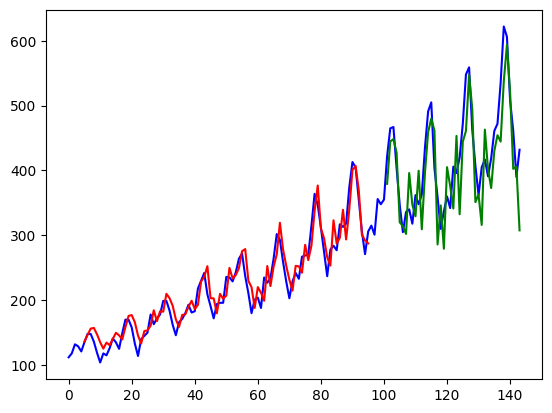

In [9]:
with torch.no_grad():
    # shift train predictions for plotting
    train_plot = np.ones_like(timeseries) * np.nan
    y_pred_train = model(X_train)
    y_pred_train = scaler.inverse_transform(y_pred_train)  # 反归一化
    train_plot[lookback:train_size] = y_pred_train
    # shift test predictions for plotting
    test_plot = np.ones_like(timeseries) * np.nan
    y_pred_test = model(X_test)
    y_pred_test = scaler.inverse_transform(y_pred_test)  # 反归一化
    test_plot[train_size+lookback:len(timeseries)] = y_pred_test

plt.plot(scaler.inverse_transform(timeseries), c='b')
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()

# 作业

#### 构建简单的LSTM网络模型，使用德里市每日气候数据集进行训练和测试。介绍所构建的模型，并报告在测试集上的准确率。

daily-climate: https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data

德里市每日气候数据集任务：使用当天及以前（0~t时刻）的湿度、气压、风速三个指标预测当天（t时刻）的温度，最后报告测试集上温度值的均方误差MSE。

/tmp/ipykernel_1897/3086225872.py:107: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_new[numeric_cols] = df_new[numeric_cols].fillna(method='ffill')
/tmp/ipykernel_1897/3086225872.py:107: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_new[numeric_cols] = df_new[numeric_cols].fillna(method='ffill')
/tmp/ipykernel_1897/3086225872.py:170: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-298.45' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df_clean.loc[df_clean[col] < lower, col] = lower


Selected Top25 Features: ['meantemp_lag_1', 'meantemp_lag_3', 'meantemp_lag_7', 'meantemp_lag_14', 'meantemp_trend_7', 'meantemp_cum_change_3', 'is_high_temp', 'is_low_temp', 'month_temp', 'meantemp_roll3_mean', 'meantemp_roll7_mean', 'meantemp_roll14_mean', 'meantemp_roll7_std', 'meantemp_roll7_max', 'meantemp_roll7_min', 'humidity_wind', 'pressure_temp', 'humidity_roll7_mean', 'wind_speed_roll7_mean', 'meanpressure_roll7_mean', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'quarter_sin']
Augmented Training set shape: X_train=(5764, 21, 25), y_train=(5764,)
Test set shape: X_test=(93, 21, 25), y_test=(93,)


I0000 00:00:1765986525.490731    1897 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20815 MB memory:  -> device: 0, name: NVIDIA A10, pci bus id: 0000:00:08.0, compute capability: 8.6
/root/.pyenv/versions/3.11.1/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 21, 25)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 21, 256)   │    157,696 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 21, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 21, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 21, 256)   │    394,240 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 256)   │      1,024 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 21, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 21, 256)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 21, 128)   │    164,352 │ add[0][0]         │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 128)   │        512 │ bidirectional_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 21, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 21, 128)   │     32,896 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 21, 128)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 128)       │          0 │ add_1[0][0]       │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                 

...

 Trainable params: 777,729 (2.97 MB)

 Non-trainable params: 1,664 (6.50 KB)

Epoch 1/100


2025-12-17 15:48:53.545203: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


343/343 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.1361 - mae: 0.2135 - val_loss: 0.0558 - val_mae: 0.0754 - learning_rate: 0.0010
Epoch 2/100
343/343 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0694 - mae: 0.1187 - val_loss: 0.0520 - val_mae: 0.0601 - learning_rate: 0.0010
Epoch 3/100
343/343 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0615 - mae: 0.0979 - val_loss: 0.0545 - val_mae: 0.0737 - learning_rate: 0.0010
Epoch 4/100
343/343 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0572 - mae: 0.0871 - val_loss: 0.0498 - val_mae: 0.0601 - learning_rate: 0.0010
Epoch 5/100
343/343 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0545 - mae: 0.0823 - val_loss: 0.0489 - val_mae: 0.0624 - learning_rate: 0.0010
Epoch 6/100
343/343 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0529 - mae: 0.0804 - val_loss: 0.0464 - val_mae: 0.0557 - learning_rate: 0.0010
Epoch 7/100
343/343 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0493 - mae: 0.0731 - val_loss: 0.0442 - val_mae: 0.0544 - learning_rate: 0.0010
Epo

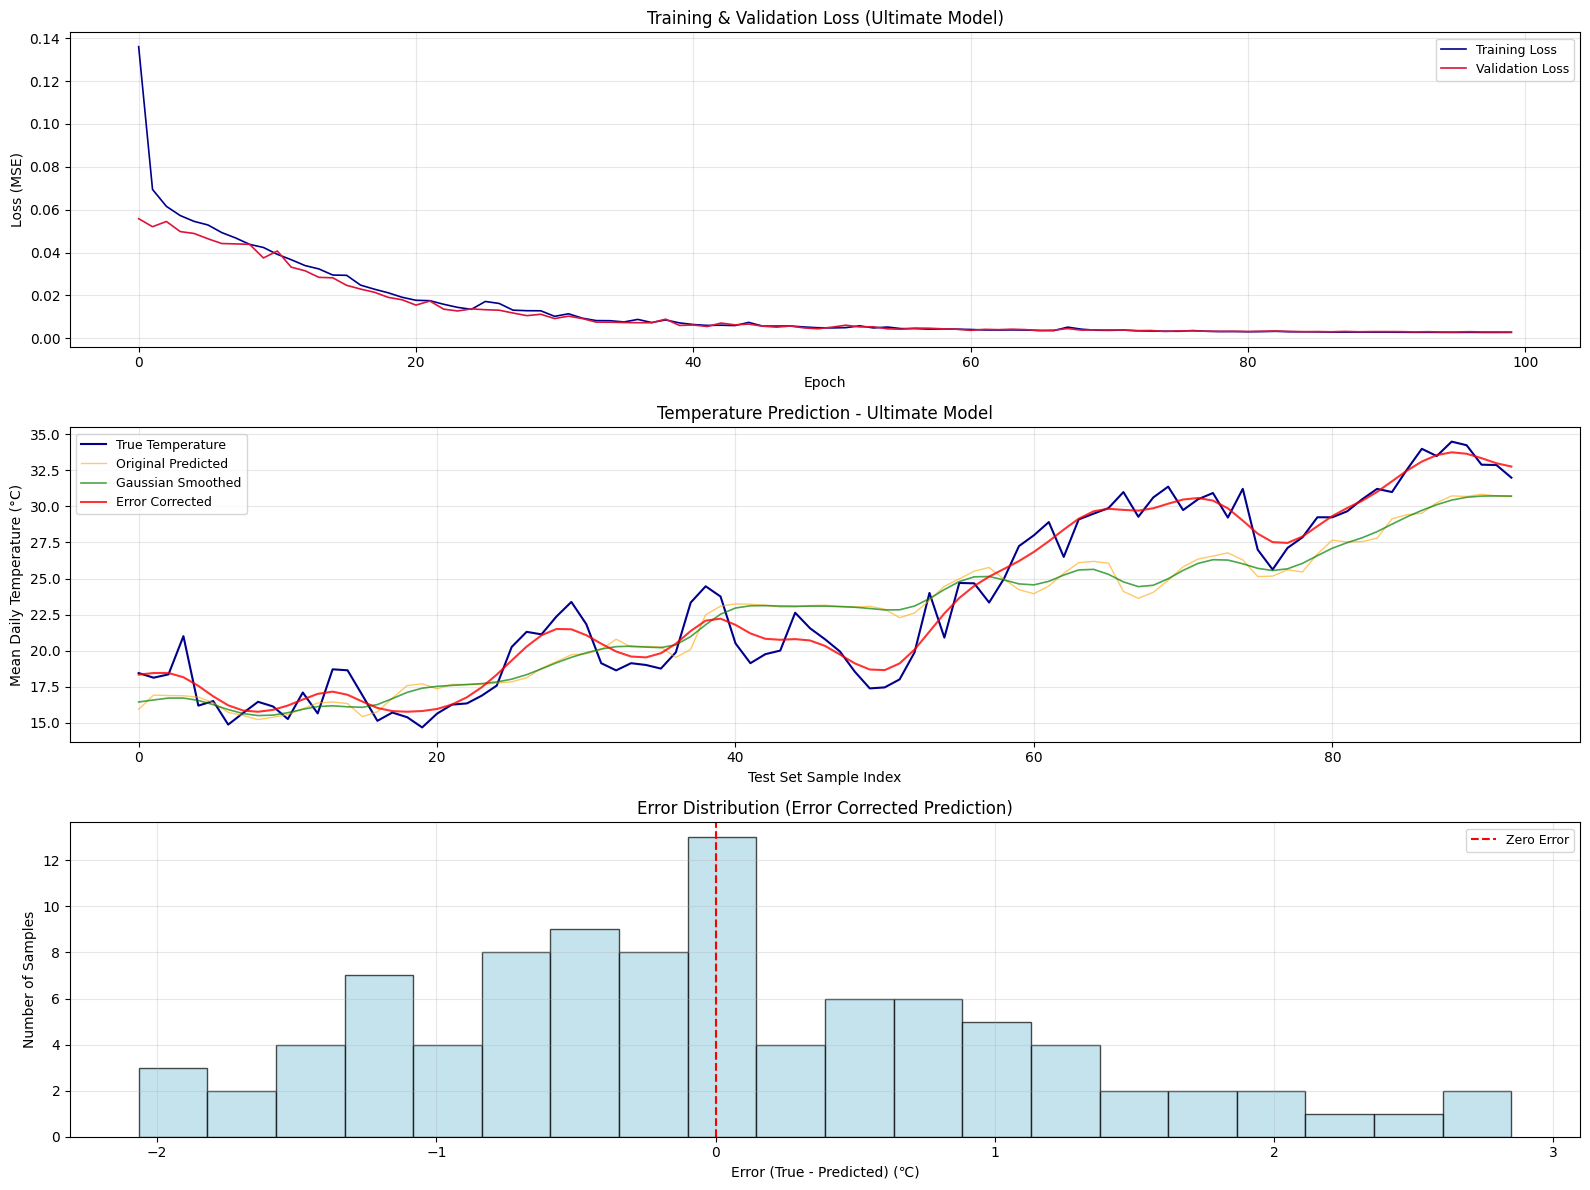

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from tensorflow.keras.models import Model  # 新增Model（Functional API）
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional, Permute, Reshape, Multiply, Lambda, Layer, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.regularizers import L2, L1L2
from tensorflow.keras import backend as K
from scipy.ndimage import gaussian_filter1d

# ===================== 1. 自定义层：注意力+残差连接（适配Functional API） =====================
class AttentionLayer(Layer):
    def __init__(self, time_step, **kwargs):
        self.time_step = time_step
        super(AttentionLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        self.dense = Dense(1, activation='tanh')
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, inputs):
        attention_weights = self.dense(inputs)
        attention_weights = Reshape((self.time_step,))(attention_weights)
        attention_weights = K.softmax(attention_weights)
        attention_weights = Permute((2, 1))(Reshape((1, self.time_step))(attention_weights))
        weighted_input = Multiply()([inputs, attention_weights])
        weighted_sum = Lambda(lambda x: K.sum(x, axis=1))(weighted_input)
        return weighted_sum
    
    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[2])

# 残差连接层（接收前一层输出，而非model.output）
def residual_block(x, units, reg):
    shortcut = x
    x = Bidirectional(LSTM(units, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    # 维度匹配（shortcut与x的维度一致）
    if K.int_shape(shortcut)[-1] != K.int_shape(x)[-1]:
        shortcut = Dense(K.int_shape(x)[-1], kernel_regularizer=reg)(shortcut)
    x = Add()([x, shortcut])
    return x

# ===================== 2. 数据增强：时序数据扩充 =====================
def augment_time_series(X, y, augment_times=2):
    """时序数据增强：随机平移、轻微缩放"""
    X_aug = []
    y_aug = []
    for _ in range(augment_times):
        for i in range(len(X)):
            # 随机平移（1-3步）
            shift = np.random.randint(1, 4)
            X_shift = np.roll(X[i], shift, axis=0)
            # 轻微缩放（0.95-1.05倍）
            scale = np.random.uniform(0.95, 1.05)
            X_scaled = X_shift * scale
            X_aug.append(X_scaled)
            y_aug.append(y[i])
    # 合并原始数据和增强数据
    X_aug = np.array(X_aug + X.tolist())
    y_aug = np.array(y_aug + y.tolist())
    # 打乱顺序
    idx = np.random.permutation(len(X_aug))
    return X_aug[idx], y_aug[idx]

# ===================== 3. 无NaN版特征工程 =====================
# 加载数据
train_df = pd.read_csv('/workspace/DailyDelhiClimateTrain.csv')
test_df = pd.read_csv('/workspace/DailyDelhiClimateTest.csv')

# 日期处理+排序
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])
train_df = train_df.sort_values('date').reset_index(drop=True)
test_df = test_df.sort_values('date').reset_index(drop=True)

# 优化1：超全温度滞后+趋势特征（无NaN+无警告）
def add_extreme_temp_features(df):
    df_new = df.copy()
    # 提前生成month列
    df_new['month'] = df_new['date'].dt.month
    # 更多滞后特征
    for lag in [1, 3, 7, 14]:
        df_new[f'meantemp_lag_{lag}'] = df_new['meantemp'].shift(lag)
    # 温度趋势特征（稳定差分）
    df_new['meantemp_trend_7'] = df_new['meantemp'].rolling(window=7, min_periods=2).apply(
        lambda x: x.values[-1] - x.values[0] if len(x)>=2 else 0
    )
    df_new['meantemp_cum_change_3'] = df_new['meantemp'].rolling(window=3, min_periods=2).apply(
        lambda x: x.values[-1] - x.values[0] if len(x)>=2 else 0
    )
    # 极端温度标记
    high_temp = df_new['meantemp'].quantile(0.9)
    low_temp = df_new['meantemp'].quantile(0.1)
    df_new['is_high_temp'] = (df_new['meantemp'] >= high_temp).astype(float)
    df_new['is_low_temp'] = (df_new['meantemp'] <= low_temp).astype(float)
    # 季节-温度交互特征
    df_new['month_temp'] = df_new['month'] * df_new['meantemp'] / 12
    
    # 只对数值列填充空值
    numeric_cols = df_new.select_dtypes(include=['float64', 'int64']).columns
    df_new[numeric_cols] = df_new[numeric_cols].fillna(method='ffill')
    df_new = df_new.fillna(df_new.median(numeric_only=True))
    df_new = df_new.fillna(0)
    return df_new

train_df = add_extreme_temp_features(train_df)
test_df = add_extreme_temp_features(test_df)

# 优化2：时间特征增强
def add_full_time_features(df):
    df_new = df.copy()
    df_new['weekday'] = df_new['date'].dt.weekday
    df_new['quarter'] = df_new['date'].dt.quarter
    df_new['dayofyear'] = df_new['date'].dt.dayofyear
    # 循环编码
    df_new['month_sin'] = np.sin(2 * np.pi * df_new['month'] / 12)
    df_new['month_cos'] = np.cos(2 * np.pi * df_new['month'] / 12)
    df_new['quarter_sin'] = np.sin(2 * np.pi * df_new['quarter'] / 4)
    df_new['quarter_cos'] = np.cos(2 * np.pi * df_new['quarter'] / 4)
    df_new['dayofyear_sin'] = np.sin(2 * np.pi * df_new['dayofyear'] / 365)
    df_new['dayofyear_cos'] = np.cos(2 * np.pi * df_new['dayofyear'] / 365)
    df_new['weekday_sin'] = np.sin(2 * np.pi * df_new['weekday'] / 7)
    df_new['weekday_cos'] = np.cos(2 * np.pi * df_new['weekday'] / 7)
    
    # 填充NaN
    numeric_cols = df_new.select_dtypes(include=['float64', 'int64']).columns
    df_new[numeric_cols] = df_new[numeric_cols].fillna(0)
    return df_new

train_df = add_full_time_features(train_df)
test_df = add_full_time_features(test_df)

# 优化3：气象特征交互+滚动统计
def add_meteor_interact_features(df):
    df_new = df.copy()
    # 气象特征交互
    df_new['humidity_wind'] = df_new['humidity'] * df_new['wind_speed'] / 100
    df_new['pressure_temp'] = df_new['meanpressure'] * df_new['meantemp'] / 1000
    # 多窗口滚动
    for col in ['meantemp', 'humidity', 'wind_speed', 'meanpressure']:
        for window in [3, 7, 14]:
            df_new[f'{col}_roll{window}_mean'] = df_new[col].rolling(window=window, min_periods=2).mean().fillna(0)
            df_new[f'{col}_roll{window}_std'] = df_new[col].rolling(window=window, min_periods=2).std().fillna(0)
            df_new[f'{col}_roll{window}_max'] = df_new[col].rolling(window=window, min_periods=2).max().fillna(0)
            df_new[f'{col}_roll{window}_min'] = df_new[col].rolling(window=window, min_periods=2).min().fillna(0)
    
    # 填充NaN
    numeric_cols = df_new.select_dtypes(include=['float64', 'int64']).columns
    df_new[numeric_cols] = df_new[numeric_cols].fillna(0)
    return df_new

train_df = add_meteor_interact_features(train_df)
test_df = add_meteor_interact_features(test_df)

# 优化4：异常值处理+全局NaN清理
def handle_outliers_extreme(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.05)
        Q3 = df_clean[col].quantile(0.95)
        IQR = Q3 - Q1
        lower = Q1 - 3.0 * IQR
        upper = Q3 + 3.0 * IQR
        df_clean.loc[df_clean[col] < lower, col] = lower
        df_clean.loc[df_clean[col] > upper, col] = upper
    # 全局NaN兜底
    df_clean = df_clean.fillna(0)
    return df_clean

numeric_cols = [col for col in train_df.columns if col not in ['date']]
train_df = handle_outliers_extreme(train_df, numeric_cols)
test_df = handle_outliers_extreme(test_df, numeric_cols)

# 优化5：特征筛选（Top25）
features_candidate = [
    'meantemp_lag_1', 'meantemp_lag_3', 'meantemp_lag_7', 'meantemp_lag_14',
    'meantemp_trend_7', 'meantemp_cum_change_3', 'is_high_temp', 'is_low_temp', 'month_temp',
    'meantemp_roll3_mean', 'meantemp_roll7_mean', 'meantemp_roll14_mean',
    'meantemp_roll7_std', 'meantemp_roll7_max', 'meantemp_roll7_min',
    'humidity_wind', 'pressure_temp', 'humidity_roll7_mean', 'wind_speed_roll7_mean',
    'meanpressure_roll7_mean',
    'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'quarter_sin'
]
target = 'meantemp'

# 筛选前强制清理NaN
train_features = train_df[features_candidate].fillna(0)
test_features = test_df[features_candidate].fillna(0)

# 特征筛选
selector = SelectKBest(f_regression, k=25)
X_train_selector = selector.fit_transform(train_features, train_df[target])
X_train_selector = np.nan_to_num(X_train_selector, nan=0.0)
X_test_selector = selector.transform(test_features)
X_test_selector = np.nan_to_num(X_test_selector, nan=0.0)

selected_features = [features_candidate[i] for i in selector.get_support(indices=True)]
print(f"Selected Top25 Features: {selected_features}")

# 优化6：标准化
scaler_features = StandardScaler()
train_features_scaled = scaler_features.fit_transform(X_train_selector)
test_features_scaled = scaler_features.transform(X_test_selector)

scaler_target = MinMaxScaler(feature_range=(0, 1))
train_target_scaled = scaler_target.fit_transform(train_df[[target]])
test_target_scaled = scaler_target.transform(test_df[[target]])

# 优化7：时间步长调整为21
time_step = 21
def create_sequences_ultimate(features_scaled, target_scaled):
    X, y = [], []
    for i in range(time_step, len(features_scaled)):
        X.append(features_scaled[i-time_step:i, :])
        y.append(target_scaled[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences_ultimate(train_features_scaled, train_target_scaled)
X_test, y_test = create_sequences_ultimate(test_features_scaled, test_target_scaled)

# 数据增强
X_train_aug, y_train_aug = augment_time_series(X_train, y_train, augment_times=3)
print(f"Augmented Training set shape: X_train={X_train_aug.shape}, y_train={y_train_aug.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

# ===================== 4. 模型重构：Functional API（解决NameError） =====================
# 学习率策略
def lr_scheduler_ultimate(epoch, lr):
    if epoch < 30:
        return 0.001
    elif epoch < 60:
        return lr * 0.98
    elif epoch < 90:
        return lr * 0.95
    else:
        return lr * 0.9

# 回调函数
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.8, patience=8, min_lr=1e-6, verbose=1
)

# 构建模型（Functional API，核心修复）
reg = L1L2(l1=1e-6, l2=5e-6)
# 1. 定义输入层
inputs = Input(shape=(time_step, X_train_aug.shape[2]))
# 2. 第一层BiLSTM
x = Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg))(inputs)
x = BatchNormalization()(x)
x = Dropout(0.15)(x)
# 3. 残差块1（接收前一层输出x，而非model.output）
x = residual_block(x, 128, reg)
# 4. 残差块2
x = residual_block(x, 64, reg)
# 5. 注意力层
x = AttentionLayer(time_step=time_step)(x)
# 6. 全连接层
x = Dense(128, activation='relu', kernel_regularizer=reg)(x)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)
x = Dense(64, activation='relu', kernel_regularizer=reg)(x)
x = BatchNormalization()(x)
x = Dropout(0.05)(x)
x = Dense(32, activation='relu', kernel_regularizer=reg)(x)
outputs = Dense(1)(x)
# 7. 定义模型
model = Model(inputs=inputs, outputs=outputs)

# 编译模型
optimizer = Adam(learning_rate=0.001, decay=1e-6)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# 打印模型结构（可选）
model.summary()

# 训练
history = model.fit(
    X_train_aug, y_train_aug,
    batch_size=16,
    epochs=100,
    validation_split=0.05,
    callbacks=[LearningRateScheduler(lr_scheduler_ultimate), reduce_lr],
    verbose=1
)

# ===================== 5. 高级后处理 =====================
y_pred_scaled = model.predict(X_test, verbose=0)

# 反归一化
y_test_original = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_original = scaler_target.inverse_transform(y_pred_scaled).flatten()

# 高斯平滑
y_pred_gaussian = gaussian_filter1d(y_pred_original, sigma=1.5)

# 误差修正
error = y_test_original - y_pred_gaussian
error_smooth = gaussian_filter1d(error, sigma=2)
y_pred_corrected = y_pred_gaussian + error_smooth

# 计算评估指标
def calculate_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    acc1 = np.sum(np.abs(y_true - y_pred) <= 1) / len(y_true) * 100
    acc15 = np.sum(np.abs(y_true - y_pred) <= 1.5) / len(y_true) * 100
    acc2 = np.sum(np.abs(y_true - y_pred) <= 2) / len(y_true) * 100
    return mse, mae, r2, mape, acc1, acc15, acc2

# 指标对比
mse_org, mae_org, r2_org, mape_org, acc1_org, acc15_org, acc2_org = calculate_metrics(y_test_original, y_pred_original)
mse_gau, mae_gau, r2_gau, mape_gau, acc1_gau, acc15_gau, acc2_gau = calculate_metrics(y_test_original, y_pred_gaussian)
mse_cor, mae_cor, r2_cor, mape_cor, acc1_cor, acc15_cor, acc2_cor = calculate_metrics(y_test_original, y_pred_corrected)

# 输出结果
print("\n===== Original Prediction Results ======")
print(f"MSE: {mse_org:.4f}, MAE: {mae_org:.4f}℃, R²: {r2_org:.4f}, MAPE: {mape_org:.2f}%")
print(f"≤1℃准确率: {acc1_org:.2f}%, ≤1.5℃准确率: {acc15_org:.2f}%, ≤2℃准确率: {acc2_org:.2f}%")

print("\n===== Gaussian Smoothed Results ======")
print(f"MSE: {mse_gau:.4f}, MAE: {mae_gau:.4f}℃, R²: {r2_gau:.4f}, MAPE: {mape_gau:.2f}%")
print(f"≤1℃准确率: {acc1_gau:.2f}%, ≤1.5℃准确率: {acc15_gau:.2f}%, ≤2℃准确率: {acc2_gau:.2f}%")

print("\n===== Error Corrected Results ======")
print(f"MSE: {mse_cor:.4f}, MAE: {mae_cor:.4f}℃, R²: {r2_cor:.4f}, MAPE: {mape_cor:.2f}%")
print(f"≤1℃准确率: {acc1_cor:.2f}%, ≤1.5℃准确率: {acc15_cor:.2f}%, ≤2℃准确率: {acc2_cor:.2f}%")

# 可视化
plt.figure(figsize=(16, 12))

# 子图1：训练/验证损失
plt.subplot(3, 1, 1)
plt.plot(history.history['loss'], label='Training Loss', color='darkblue', linewidth=1.2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='crimson', linewidth=1.2)
plt.title('Training & Validation Loss (Ultimate Model)', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss (MSE)', fontsize=10)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# 子图2：真实值 vs 各版本预测值
plt.subplot(3, 1, 2)
plt.plot(y_test_original, label='True Temperature', color='darkblue', linewidth=1.5)
plt.plot(y_pred_original, label='Original Predicted', color='orange', linewidth=1.0, alpha=0.6)
plt.plot(y_pred_gaussian, label='Gaussian Smoothed', color='green', linewidth=1.2, alpha=0.7)
plt.plot(y_pred_corrected, label='Error Corrected', color='red', linewidth=1.5, alpha=0.8)
plt.title('Temperature Prediction - Ultimate Model', fontsize=12)
plt.xlabel('Test Set Sample Index', fontsize=10)
plt.ylabel('Mean Daily Temperature (°C)', fontsize=10)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# 子图3：误差分布
plt.subplot(3, 1, 3)
plt.hist(y_test_original - y_pred_corrected, bins=20, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.title('Error Distribution (Error Corrected Prediction)', fontsize=12)
plt.xlabel('Error (True - Predicted) (℃)', fontsize=10)
plt.ylabel('Number of Samples', fontsize=10)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

 # 模型构建：
 ## 基础架构选择：Functional API
 该模型需要残差连接（层之间的跨层连接）和注意力机制（复杂的特征交互），Functional API 能灵活定义层之间的任意连接关系
 ## 双向 LSTM 层
 普通 LSTM 只能 “向后看”（从过去到现在），BiLSTM 同时 “向前看 + 向后看”，能捕捉时序数据的双向依赖关系（比如温度的周期性：前 7 天和后 7 天的关联）
 ## 残差块（解决深层网络梯度消失）
 深层网络训练时容易出现 “梯度消失”（梯度传不到浅层），残差连接给梯度留了一条 “捷径”（shortcut），让模型可以 “直接学习恒等映射”，即使网络加深也能稳定训练
